# OWS Styling

Reference pages on testing styling in a notebook before switching to the datacube ows config:
- Applying style to xarray Dataset: https://datacube-ows.readthedocs.io/en/latest/cfg_style_api.html
- Testing styles in notebook: https://datacube-ows.readthedocs.io/en/latest/styling_howto.html
- Color ramp: https://datacube-ows.readthedocs.io/en/latest/style_howto_color_ramp.html
- Legends: https://datacube-ows.readthedocs.io/en/latest/style_howto_legends.html

In [1]:
from datacube import Datacube
# Area of interest
from importlib.resources import files
import geopandas as gpd
from odc.geo.geom import Geometry

In [2]:
dc = Datacube()

In [3]:
# View product description
products_df = dc.list_products()
products_df[products_df["name"].isin(["wq_annual"])]

,name,description,license,default_crs,default_resolution
name,,,,,
wq_annual,wq_annual,DE Africa Water Quality Service annual water q...,CC-BY-4.0,EPSG:6933,"Resolution(x=10, y=-10)"


In [4]:
# List measurements
measurements_df = dc.list_measurements()
measurements_df.query("product == 'wq_annual'")

name    dtype            units  nodata  \
product   measurement                                                          
wq_annual agm_fai                  agm_fai  float32                1     NaN   
          agm_hue                  agm_hue  float32          degrees     NaN   
          agm_ndvi                agm_ndvi  float32                1     NaN   
          agm_owt                  agm_owt  float32                1     NaN   
          chla                        chla  float32                1     NaN   
          clear_water          clear_water  float32                1     NaN   
          tirs_st_ann_max  tirs_st_ann_max  float32  degrees Celsius     NaN   
          tirs_st_ann_med  tirs_st_ann_med  float32  degrees Celsius     NaN   
          tirs_st_ann_min  tirs_st_ann_min  float32  degrees Celsius     NaN   
          tsi                          tsi  float32                1     NaN   
          tsm                          tsm  float32                1     NaN   
          water_mask            water_mask  float32                1     NaN   

                                                           aliases  \
product   measurement                                                
wq_annual agm_fai                 [fai, FAI, floating_algae_index]   
          agm_hue                                       [hue, HUE]   
          agm_ndvi                                    [ndvi, NDVI]   
          agm_owt                   [owt, OWT, optical_water_type]   
          chla                               [CHLA, chlorophyll_a]   
          clear_water                                          NaN   
          tirs_st_ann_max        [st_max, max_surface_temperature]   
          tirs_st_ann_med  [st_median, median_surface_temperature]   
          tirs_st_ann_min        [st_min, min_surface_temperature]   
          tsi                           [TSI, trophic_state_index]   
          tsm                        [TSM, total_suspended_matter]   
          water_mask                                           NaN   

                           add_offset  scale_factor  \
product   measurement                                 
wq_annual agm_fai                 0.0           1.0   
          agm_hue                 0.0           1.0   
          agm_ndvi                0.0           1.0   
          agm_owt                 0.0           1.0   
          chla                    0.0           1.0   
          clear_water             0.0           1.0   
          tirs_st_ann_max         0.0           1.0   
          tirs_st_ann_med         0.0           1.0   
          tirs_st_ann_min         0.0           1.0   
          tsi                     0.0           1.0   
          tsm                     0.0           1.0   
          water_mask              0.0           1.0   

                                                            flags_definition  
product   measurement                                                         
wq_annual agm_fai                                                        NaN  
          agm_hue                                                        NaN  
          agm_ndvi                                                       NaN  
          agm_owt          {'mask': {'bits': [0, 1, 2, 3], 'values': {'1'...  
          chla                                                           NaN  
          clear_water                                                    NaN  
          tirs_st_ann_max                                                NaN  
          tirs_st_ann_med                                                NaN  
          tirs_st_ann_min                                                NaN  
          tsi                                                            NaN  
          tsm                                                            NaN  
          water_mask                                                     NaN

In [5]:
places_fp = "https://raw.githubusercontent.com/vikineema/deafrica_water_quality/main/src/water_quality/data/places.parquet"
import requests
import io
response = requests.get(places_fp)
response.raise_for_status()

places_gdf = gpd.read_parquet(io.BytesIO(response.content))
place_name_list = places_gdf["name"].to_list()

place_name = "SA_smalldam1"
place = places_gdf[places_gdf["name"].isin([place_name])]
aoi_geom = Geometry(geom=place.iloc[0].geometry, crs=place.crs)

In [6]:
aoi_geom.explore()

In [7]:
ds = dc.load(
    product="wq_annual",
    time=("2024"),
    geopolygon=aoi_geom,
    measurements=["tsi"],
    output_crs="EPSG:6933",
    resolution=(-10,10)
)
ds

<xarray.Dataset> Size: 8kB
Dimensions:      (time: 1, y: 39, x: 49)
Coordinates:
  * time         (time) datetime64[ns] 8B 2024-07-01T23:59:59.999999
  * y            (y) float64 312B -4.072e+06 -4.072e+06 ... -4.073e+06
  * x            (x) float64 392B 1.882e+06 1.882e+06 ... 1.882e+06 1.882e+06
    spatial_ref  int32 4B 6933
Data variables:
    tsi          (time, y, x) float32 8kB nan nan nan nan ... nan nan nan nan
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

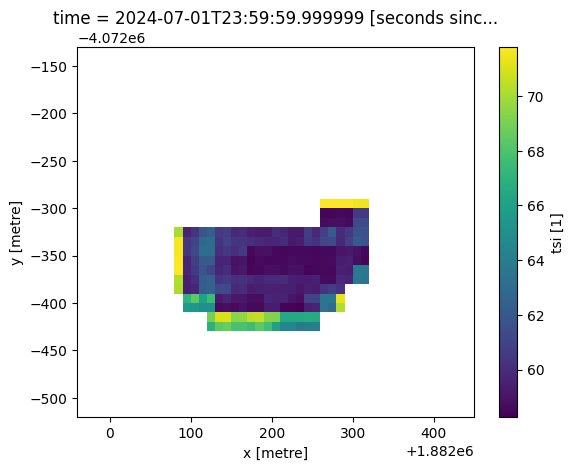

In [8]:
ds["tsi"].plot()

In [9]:
#import sys
#sys.path.append("/home/jovyan/services/")
#from water_quality.style_wq_annual_cfg import color_ramp_chla, legend_chla, style_wq_annual_chla

In [39]:
# ============================================================================
# TROPHIC STATE INDEX (TSI) STYLES
# ============================================================================
legend_tsi = {
    "show_legend": True,
    "title": "Trophic State (index) ",
    "units": "",
    "begin": "0",
    "end": "100.0",
    "ticks": ['0.0','10.0','20.0','30.0','40.0','50.0','60.0','70.0','80.0','90.0', '100.0'],
    "tick_labels" : {
        "0.0": {"label": "0"},
        "10.0": {"label": "10"},
        "20.0": {"label": "20"},
        "30.0": {"label": "30"},
        "40.0": {"label": "40"},
        "50.0": {"label": "50"},
        "60.0": {"label": "60"},
        "70.0": {"label": "70"},
        "80.0": {"label": "80"},
        "90.0": {"label": "90"},
        "100.0": {"label": "100"},},
        "width": 4.5,
        "height": 2.1,
        "strip_location": [0.1, 0.4, 0.8, 0.2],
    }

style_wq_annual_tsi = {
    "name": "wq_annual_tsi",
    "title": "Trophic State Index",
    "abstract": "Biological productivity in surface water bodies",
    "legend": legend_tsi,
    "index_function": {
        "function": "datacube_ows.band_utils.single_band",
        "mapped_bands": True,
        "kwargs": {"band": "tsi"},
    },
    "needed_bands": ["tsi"],
    "include_in_feature_info": True,
    "color_ramp": [
        {"value": 0.0, "color": "#5e4fa2"},    # 0 - Purple (oligotrophic)
        {"value": 10.0, "color": "#3288bd"},   # 10 - Blue
        {"value": 20.0, "color": "#66c2a5"},   # 20 - Cyan
        {"value": 30.0, "color": "#abdda4"},   # 30 - Light cyan-green
        {"value": 40.0, "color": "#e6f598"},   # 40 - Pale green-yellow (mesotrophic)
        {"value": 50.0, "color": "#ffffbf"},   # 50 - Pale yellow
        {"value": 60.0, "color": "#fee08b"},   # 60 - Light yellow
        {"value": 70.0, "color": "#fdae61"},   # 70 - Orange-yellow (eutrophic)
        {"value": 75.0, "color": "#f46d43"},   # 75 - Orange
        {"value": 80.0, "color": "#d53e4f"},   # 80 - Red-orange
        {"value": 90.0, "color": "#9e0142"},   # 90 - Dark red (hypereutrophic)
        {"value": 100.0, "color": "#67001f"},  # 100 - Very dark red
    ],
}


In [13]:
# ============================================================================
# TROPHIC STATE INDEX (TSI) STYLES
# ============================================================================
legend_tsi = {
    "show_legend": True,
    "title": "Trophic State (index) ",
    "units": "",
    "begin": "0.0",
    "end": "100.0",
    "decimal_places": 1,
    "ticks_every": "10",
}
style_wq_annual_tsi = {
    "name": "wq_annual_tsi",
    "title": "Trophic State Index",
    "abstract": "Biological productivity in surface water bodies",
    "legend": legend_tsi,
    "index_function": {
        "function": "datacube_ows.band_utils.single_band",
        "mapped_bands": True,
        "kwargs": {"band": "tsi"},
    },
    "needed_bands": ["tsi"],
    "include_in_feature_info": True,
    "color_ramp": [
        {"value": 0.0, "color": "#5e4fa2"},    # 0 - Purple (oligotrophic)
        {"value": 10.0, "color": "#3288bd"},   # 10 - Blue
        {"value": 20.0, "color": "#66c2a5"},   # 20 - Cyan
        {"value": 30.0, "color": "#abdda4"},   # 30 - Light cyan-green
        {"value": 40.0, "color": "#e6f598"},   # 40 - Pale green-yellow (mesotrophic)
        {"value": 50.0, "color": "#ffffbf"},   # 50 - Pale yellow
        {"value": 60.0, "color": "#fee08b"},   # 60 - Light yellow
        {"value": 70.0, "color": "#fdae61"},   # 70 - Orange-yellow (eutrophic)
        {"value": 75.0, "color": "#f46d43"},   # 75 - Orange
        {"value": 80.0, "color": "#d53e4f"},   # 80 - Red-orange
        {"value": 90.0, "color": "#9e0142"},   # 90 - Dark red (hypereutrophic)
        {"value": 100.0, "color": "#67001f"},  # 100 - Very dark red
    ],
}


In [14]:
from datacube_ows.styles.api import generate_ows_legend_style_cfg

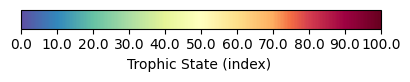

In [15]:
image = generate_ows_legend_style_cfg(style_wq_annual_tsi)

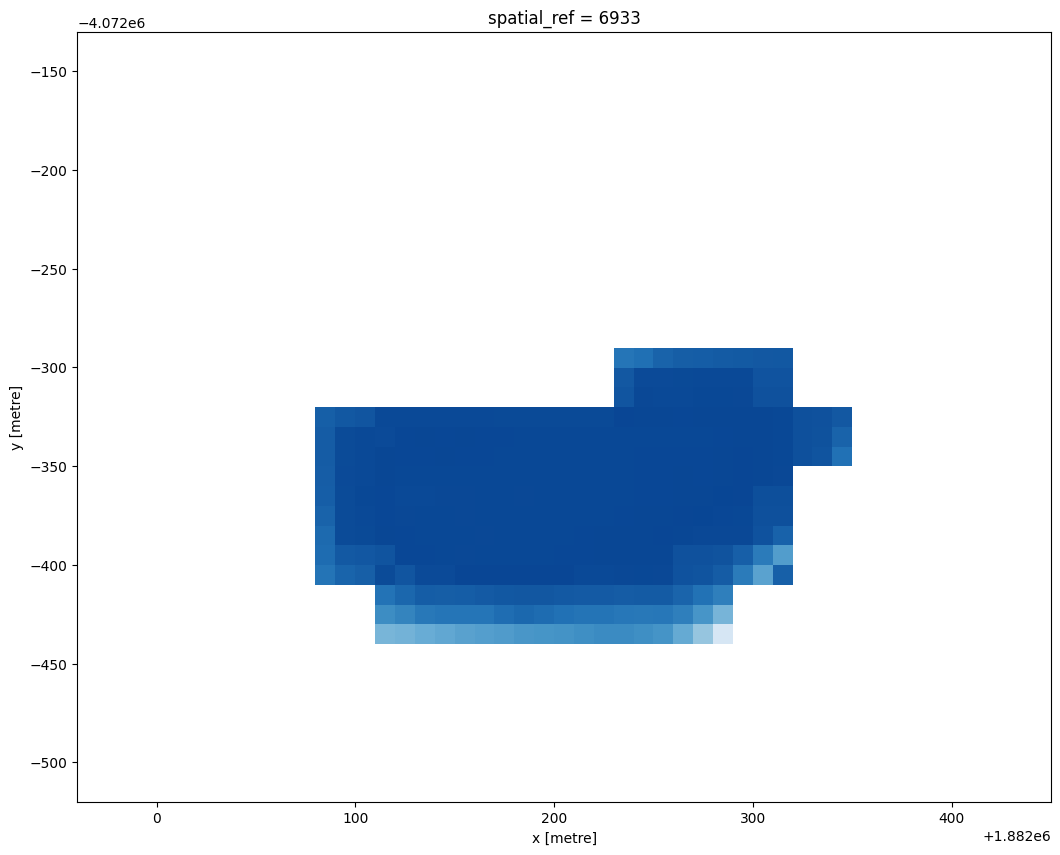

In [25]:
plot_image_with_style_cfg(custom_ramp_cfg, ds)

In [24]:
xr_image = apply_ows_style_cfg(custom_ramp_cfg, ds)

/opt/venv/lib/python3.12/site-packages/datacube_ows/styles/ramp.py:250: RuntimeWarning: invalid value encountered in cast
  return val.astype(ubyte)


In [23]:
png_image = xarray_image_as_png(xr_image)

In [24]:
with open("example1.png", "wb") as fp:
     fp.write(png_image)